Define start and target states.

Save nodes that were visited. Define target check and empty check.

In [1]:
TARGET = [(1,2,3), (4,5,6), (7,8,0)]
used = []

In [2]:
def read_data(nums):
    return [tuple(nums[0:3]),tuple(nums[3:6]),tuple(nums[6:9])]

In [3]:
START = read_data([1,5,8,4,6,0,3,2,7])
START

[(1, 5, 8), (4, 6, 0), (3, 2, 7)]

In [4]:
def goal_test(state):
    return 1 if state == TARGET else 0

In [5]:
print(goal_test(START))

goal_test(TARGET)

0


1

(1, 5, 8)
(4, 6, 0)
(3, 2, 7)

In [6]:
used.append(START)

used - set of visited nodes, check each node

In [39]:
# get zero position to further identify where we can go
def empty(state):
    for i in range(3):
        for j in range(3):
            if state[i][j] == 0:
                return(i, j)

We can move the neighbors of the 0 pos

In [40]:
empty(START)

(2, 0)

can move 8, 6,7

Each node -> ome children. For each node call a function that generates children (possible mves).


if pos is 1 1 then check 01 10 21 12 

so + / - 1 to each index

Iterate over all values. Once there's zero near the current value (above, below, to the left or to the right), we create a new node by swapping the values and saving it to the tree list/

In [11]:
state = START

state

[(1, 5, 8), (4, 6, 0), (3, 2, 7)]

In [12]:
# state = START
# states = []
# for i in range(3):         
#     for j in range(3):    
    
#         if state[i][j] == 0: 
#             continue
    
#         # find out if there's a neighbor state
#         # if true - create a copy and swap 0 with its neighbor
#         if state[i-1][j] == 0 and i>0: #up
#             move = state.copy()
            

#         if state[i][j-1] == 0 and j>0: # left
#             pass

#         if state[i+1][j] == 0 and i<2: #
#             pass

#         if state[i][j+1] == 0 and j<2: 
#             pass

SyntaxError: invalid syntax (2198183534.py, line 18)

redundancy. why not to find zero and create states by swapping it with its neighbors.


In [11]:
zero = empty(state)
zero

(1, 2)

In [71]:
move = [list(i) for i in state].copy()
temp = move[zero[0]+1][zero[1]]
move[zero[0]+1][zero[1]] = move[zero[0]][zero[1]]
move[zero[0]][zero[1]] = temp


In [72]:
move

[[1, 5, 8], [4, 6, 7], [3, 2, 0]]

In [67]:
all_states

[[[1, 5, 0], [4, 6, 8], [3, 2, 7]],
 [[1, 5, 0], [4, 6, 8], [3, 2, 7]],
 [[1, 5, 0], [4, 6, 8], [3, 2, 7]],
 [(1, 5, 0), (4, 6, 8), (3, 2, 7)]]

In [64]:
state

[(1, 5, 8), (4, 6, 0), (3, 2, 7)]

In [12]:
# # max 4 moves
# zero = empty(state)
# all_states=[]

# if zero[0]>0: # zero goes up
#     move = [list(i) for i in state].copy()
#     temp = move[zero[0]-1][zero[1]]
#     move[zero[0]-1][zero[1]] = move[zero[0]][zero[1]]
#     move[zero[0]][zero[1]] = temp
#     all_states.append([tuple(i) for i in move])
           

# if zero[1]>0: #left
#     move = [list(i) for i in state].copy()
#     temp = move[zero[0]][zero[1]-1]
#     move[zero[0]][zero[1]-1] = move[zero[0]][zero[1]]
#     move[zero[0]][zero[1]] = temp
#     all_states.append([tuple(i) for i in move])

# if zero[1]<2: #right
#     move = [list(i) for i in state].copy()
#     temp = move[zero[0]][zero[1]+1]
#     move[zero[0]][zero[1]+1] = move[zero[0]][zero[1]]
#     move[zero[0]][zero[1]] = temp
#     all_states.append([tuple(i) for i in move])

# if zero[0]<2: #down 
#     move = [list(i) for i in state].copy()
#     temp = move[zero[0]+1][zero[1]]
#     move[zero[0]+1][zero[1]] = move[zero[0]][zero[1]]
#     move[zero[0]][zero[1]] = temp
#     all_states.append([tuple(i) for i in move])

In [13]:
all_states

[[(1, 5, 0), (4, 6, 8), (3, 2, 7)],
 [(1, 5, 8), (4, 0, 6), (3, 2, 7)],
 [(1, 5, 8), (4, 6, 7), (3, 2, 0)]]

saved all moves from the node that is considered now

do the same for each of the states in the list, update dynamicalluy

queue will be increased and descreased, so eventually it will be empty. do until it is empty.

In [8]:
def children(state):

    #for a state compute possible moves and return a list of such moves
    zero = empty(state)
    moves = []

    if zero[0]>0: # zero goes up
        move = [list(i) for i in state].copy()
        temp = move[zero[0]-1][zero[1]]
        move[zero[0]-1][zero[1]] = move[zero[0]][zero[1]]
        move[zero[0]][zero[1]] = temp
        moves.append([tuple(i) for i in move])
               
    
    if zero[1]>0: #left
        move = [list(i) for i in state].copy()
        temp = move[zero[0]][zero[1]-1]
        move[zero[0]][zero[1]-1] = move[zero[0]][zero[1]]
        move[zero[0]][zero[1]] = temp
        moves.append([tuple(i) for i in move])
    
    if zero[1]<2: #right
        move = [list(i) for i in state].copy()
        temp = move[zero[0]][zero[1]+1]
        move[zero[0]][zero[1]+1] = move[zero[0]][zero[1]]
        move[zero[0]][zero[1]] = temp
        moves.append([tuple(i) for i in move])
    
    if zero[0]<2: #down 
        move = [list(i) for i in state].copy()
        temp = move[zero[0]+1][zero[1]]
        move[zero[0]+1][zero[1]] = move[zero[0]][zero[1]]
        move[zero[0]][zero[1]] = temp
        moves.append([tuple(i) for i in move])

    return moves

#### ~TODO: wrap into function~

Could be more optimal, but it works and so far it's ok.

In [9]:
# for move in children(START):
#     #check if not in the list already
#     all_states.append(move)

create connections


In [10]:

# while True:

In [6]:
from collections import deque

In [12]:
queue = deque()
queue.append(START)

In [13]:
queue.popleft()

[(1, 5, 8), (4, 6, 0), (3, 2, 7)]

In [17]:
queue = deque()
queue.append(START)
node = queue.popleft()
if goal_test(node):
    print('ggg')

for child in children(node):
    print(child)

[(1, 5, 0), (4, 6, 8), (3, 2, 7)]
[(1, 5, 8), (4, 0, 6), (3, 2, 7)]
[(1, 5, 8), (4, 6, 7), (3, 2, 0)]


have to add cost because it's a uniform search


Uniform is A* with zero h(n)

https://docs.python.org/3/library/heapq.html

https://www.geeksforgeeks.org/python/heap-and-priority-queue-using-heapq-module-in-python/

In [1]:
import heapq

In [14]:

level = children(START)

queue = []
heapq.heappush(queue,[1, level])

In [13]:
queue

[[1, [[(1, 2, 3), (0, 5, 7), (6, 4, 8)], [(1, 2, 3), (6, 5, 7), (4, 0, 8)]]]]

In [35]:
heapq.heappush(queue,[2, level[0]])
heapq.heappop(queue)

[1,
 [[(1, 5, 0), (4, 6, 8), (3, 2, 7)],
  [(1, 5, 8), (4, 0, 6), (3, 2, 7)],
  [(1, 5, 8), (4, 6, 7), (3, 2, 0)]]]

START -> kids

In [46]:
queue = []
heapq.heappush(queue,[0, START])

start While with queque, with 0th state. then add new states inside

In [ ]:
price, node = heapq.heappop(queue)
price, node

In [48]:
queue

[]

In [50]:
node in used

True

## new queue version

In [15]:
# START = read_data([1,2,3,4,5,0,7,8,6]) #  one move
START = read_data([1,2,3,4,0,5,7,8,6]) # 2
START = read_data([1,2,3,6,5,7,0,4,8]) # >2

#### ~TODO check different start values~

In [16]:
queue = []
used = []
heapq.heappush(queue,[0, START])

while queue:
    price, node = heapq.heappop(queue)
    
    if goal_test(node):
        print('g')
        break
        
    if node in used:
        continue
            
    for child in children(node):
        if child not in used:
            heapq.heappush(queue, [price + 1, child])
        print(child)
    
    used.append(node)

[(1, 2, 3), (0, 5, 7), (6, 4, 8)]
[(1, 2, 3), (6, 5, 7), (4, 0, 8)]
[(0, 2, 3), (1, 5, 7), (6, 4, 8)]
[(1, 2, 3), (5, 0, 7), (6, 4, 8)]
[(1, 2, 3), (6, 5, 7), (0, 4, 8)]
[(1, 2, 3), (6, 0, 7), (4, 5, 8)]
[(1, 2, 3), (6, 5, 7), (0, 4, 8)]
[(1, 2, 3), (6, 5, 7), (4, 8, 0)]
[(2, 0, 3), (1, 5, 7), (6, 4, 8)]
[(1, 2, 3), (0, 5, 7), (6, 4, 8)]
[(1, 0, 3), (5, 2, 7), (6, 4, 8)]
[(1, 2, 3), (0, 5, 7), (6, 4, 8)]
[(1, 2, 3), (5, 7, 0), (6, 4, 8)]
[(1, 2, 3), (5, 4, 7), (6, 0, 8)]
[(1, 0, 3), (6, 2, 7), (4, 5, 8)]
[(1, 2, 3), (0, 6, 7), (4, 5, 8)]
[(1, 2, 3), (6, 7, 0), (4, 5, 8)]
[(1, 2, 3), (6, 5, 7), (4, 0, 8)]
[(1, 2, 3), (6, 5, 0), (4, 8, 7)]
[(1, 2, 3), (6, 5, 7), (4, 0, 8)]
[(0, 1, 3), (5, 2, 7), (6, 4, 8)]
[(1, 3, 0), (5, 2, 7), (6, 4, 8)]
[(1, 2, 3), (5, 0, 7), (6, 4, 8)]
[(0, 1, 3), (6, 2, 7), (4, 5, 8)]
[(1, 3, 0), (6, 2, 7), (4, 5, 8)]
[(1, 2, 3), (6, 0, 7), (4, 5, 8)]
[(0, 2, 3), (1, 6, 7), (4, 5, 8)]
[(1, 2, 3), (6, 0, 7), (4, 5, 8)]
[(1, 2, 3), (4, 6, 7), (0, 5, 8)]
[(1, 2, 3), (5

## PATH

In [15]:
for i in children(START):
    print(i, "__ ", children(i), "\n")

[(1, 2, 3), (0, 5, 7), (6, 4, 8)] __  [[(0, 2, 3), (1, 5, 7), (6, 4, 8)], [(1, 2, 3), (5, 0, 7), (6, 4, 8)], [(1, 2, 3), (6, 5, 7), (0, 4, 8)]] 

[(1, 2, 3), (6, 5, 7), (4, 0, 8)] __  [[(1, 2, 3), (6, 0, 7), (4, 5, 8)], [(1, 2, 3), (6, 5, 7), (0, 4, 8)], [(1, 2, 3), (6, 5, 7), (4, 8, 0)]] 



In [99]:
path ={}
path[tuple(START)] = 0

In [100]:
path

{((1, 2, 3), (4, 0, 5), (7, 8, 6)): 0}

TODO: change list of tuples to tuple of tuples because path must have a node as a key, so I have extra conversion. 

later

In [102]:
for i in children(START):
    path[tuple(i)] = START
path

{((1, 2, 3), (4, 0, 5), (7, 8, 6)): 0,
 ((1, 0, 3), (4, 2, 5), (7, 8, 6)): [(1, 2, 3), (4, 0, 5), (7, 8, 6)],
 ((1, 2, 3), (0, 4, 5), (7, 8, 6)): [(1, 2, 3), (4, 0, 5), (7, 8, 6)],
 ((1, 2, 3), (4, 5, 0), (7, 8, 6)): [(1, 2, 3), (4, 0, 5), (7, 8, 6)],
 ((1, 2, 3), (4, 8, 5), (7, 0, 6)): [(1, 2, 3), (4, 0, 5), (7, 8, 6)]}

In [99]:
# version with path

path={}
queue = []
used = []
heapq.heappush(queue,[0, START])

while queue:
    price, node = heapq.heappop(queue)
    
    if goal_test(node):
        print('gggg')
        break
        
    if node in used:
        continue
            
    for child in children(node):
        if child not in used:
            heapq.heappush(queue, [price + 1, child])
            
            path[tuple(child)] = node # path data,part of the tree

        # print(child)
    
    used.append(node)

gggg


In [36]:
path

{((1, 2, 3), (0, 5, 7), (6, 4, 8)): [(1, 2, 3), (6, 5, 7), (0, 4, 8)],
 ((1, 2, 3), (6, 5, 7), (4, 0, 8)): [(1, 2, 3), (6, 5, 7), (0, 4, 8)],
 ((0, 2, 3), (1, 5, 7), (6, 4, 8)): [(1, 2, 3), (0, 5, 7), (6, 4, 8)],
 ((1, 2, 3), (5, 0, 7), (6, 4, 8)): [(1, 2, 3), (0, 5, 7), (6, 4, 8)],
 ((1, 2, 3), (6, 0, 7), (4, 5, 8)): [(1, 2, 3), (6, 5, 7), (4, 0, 8)],
 ((1, 2, 3), (6, 5, 7), (4, 8, 0)): [(1, 2, 3), (6, 5, 7), (4, 0, 8)],
 ((2, 0, 3), (1, 5, 7), (6, 4, 8)): [(0, 2, 3), (1, 5, 7), (6, 4, 8)],
 ((1, 0, 3), (5, 2, 7), (6, 4, 8)): [(1, 2, 3), (5, 0, 7), (6, 4, 8)],
 ((1, 2, 3), (5, 7, 0), (6, 4, 8)): [(1, 2, 3), (5, 0, 7), (6, 4, 8)],
 ((1, 2, 3), (5, 4, 7), (6, 0, 8)): [(1, 2, 3), (5, 0, 7), (6, 4, 8)],
 ((1, 0, 3), (6, 2, 7), (4, 5, 8)): [(1, 2, 3), (6, 0, 7), (4, 5, 8)],
 ((1, 2, 3), (0, 6, 7), (4, 5, 8)): [(1, 2, 3), (6, 0, 7), (4, 5, 8)],
 ((1, 2, 3), (6, 7, 0), (4, 5, 8)): [(1, 2, 3), (6, 0, 7), (4, 5, 8)],
 ((1, 2, 3), (6, 5, 0), (4, 8, 7)): [(1, 2, 3), (6, 5, 7), (4, 8, 0)],
 ((0, 

In [110]:
path[tuple(TARGET)]

[(1, 2, 3), (4, 5, 6), (7, 0, 8)]

In [111]:
path[tuple(path[tuple(TARGET)])]

[(1, 2, 3), (4, 0, 6), (7, 5, 8)]

1- 2 -3 - goal

(0) - (1) = parents

get parent and append to the resulting path]

In [18]:
def show_path(path, node):
    # node - current point 
    if node == START:
        return [node] # last step
        
    result = show_path(path, path[tuple(node)])
    result.append(node)
    return result

https://www.geeksforgeeks.org/python/how-to-fix-recursionerror-in-python/

add this

import sys

sys.setrecursionlimit(10**6)


In [43]:
START

[(1, 2, 3), (6, 5, 7), (0, 4, 8)]

In [125]:
show_path(path, TARGET)

[[(1, 2, 3), (6, 5, 7), (0, 4, 8)],
 [(1, 2, 3), (6, 5, 7), (4, 0, 8)],
 [(1, 2, 3), (6, 0, 7), (4, 5, 8)],
 [(1, 2, 3), (6, 7, 0), (4, 5, 8)],
 [(1, 2, 3), (6, 7, 8), (4, 5, 0)],
 [(1, 2, 3), (6, 7, 8), (4, 0, 5)],
 [(1, 2, 3), (6, 0, 8), (4, 7, 5)],
 [(1, 2, 3), (0, 6, 8), (4, 7, 5)],
 [(1, 2, 3), (4, 6, 8), (0, 7, 5)],
 [(1, 2, 3), (4, 6, 8), (7, 0, 5)],
 [(1, 2, 3), (4, 6, 8), (7, 5, 0)],
 [(1, 2, 3), (4, 6, 0), (7, 5, 8)],
 [(1, 2, 3), (4, 0, 6), (7, 5, 8)],
 [(1, 2, 3), (4, 5, 6), (7, 0, 8)],
 [(1, 2, 3), (4, 5, 6), (7, 8, 0)]]

# A*

In [100]:
def h_func(state):
    return 0

# add Manhattan here and the other one 

path={}
queue = []
used = []
g = 0
heapq.heappush(queue, [g + h_func(START), g, START]) # f = g+h


while queue:
    f, g, node = heapq.heappop(queue)

    if goal_test(node):
        print("gggg")
        break

    if node in used:
        continue

    for child in children(node):
        if child not in used:
            
            # start - child + child - target
            g_child = g + 1 # increase at each level
            f_child = g_child + h_func(child) # g+h
            
            heapq.heappush(queue, [f_child, g_child, child])

            path[tuple(child)] = node # path data
            
    used.append(node)

gggg


In [46]:
path

{((1, 2, 3), (0, 5, 7), (6, 4, 8)): [(1, 2, 3), (6, 5, 7), (0, 4, 8)],
 ((1, 2, 3), (6, 5, 7), (4, 0, 8)): [(1, 2, 3), (6, 5, 7), (0, 4, 8)],
 ((0, 2, 3), (1, 5, 7), (6, 4, 8)): [(1, 2, 3), (0, 5, 7), (6, 4, 8)],
 ((1, 2, 3), (5, 0, 7), (6, 4, 8)): [(1, 2, 3), (0, 5, 7), (6, 4, 8)],
 ((1, 2, 3), (6, 0, 7), (4, 5, 8)): [(1, 2, 3), (6, 5, 7), (4, 0, 8)],
 ((1, 2, 3), (6, 5, 7), (4, 8, 0)): [(1, 2, 3), (6, 5, 7), (4, 0, 8)],
 ((2, 0, 3), (1, 5, 7), (6, 4, 8)): [(0, 2, 3), (1, 5, 7), (6, 4, 8)],
 ((1, 0, 3), (5, 2, 7), (6, 4, 8)): [(1, 2, 3), (5, 0, 7), (6, 4, 8)],
 ((1, 2, 3), (5, 7, 0), (6, 4, 8)): [(1, 2, 3), (5, 0, 7), (6, 4, 8)],
 ((1, 2, 3), (5, 4, 7), (6, 0, 8)): [(1, 2, 3), (5, 0, 7), (6, 4, 8)],
 ((1, 0, 3), (6, 2, 7), (4, 5, 8)): [(1, 2, 3), (6, 0, 7), (4, 5, 8)],
 ((1, 2, 3), (0, 6, 7), (4, 5, 8)): [(1, 2, 3), (6, 0, 7), (4, 5, 8)],
 ((1, 2, 3), (6, 7, 0), (4, 5, 8)): [(1, 2, 3), (6, 0, 7), (4, 5, 8)],
 ((1, 2, 3), (6, 5, 0), (4, 8, 7)): [(1, 2, 3), (6, 5, 7), (4, 8, 0)],
 ((0, 

In [20]:
show_path(path, TARGET)

[[(1, 2, 3), (6, 5, 7), (0, 4, 8)],
 [(1, 2, 3), (6, 5, 7), (4, 0, 8)],
 [(1, 2, 3), (6, 0, 7), (4, 5, 8)],
 [(1, 2, 3), (6, 7, 0), (4, 5, 8)],
 [(1, 2, 3), (6, 7, 8), (4, 5, 0)],
 [(1, 2, 3), (6, 7, 8), (4, 0, 5)],
 [(1, 2, 3), (6, 0, 8), (4, 7, 5)],
 [(1, 2, 3), (0, 6, 8), (4, 7, 5)],
 [(1, 2, 3), (4, 6, 8), (0, 7, 5)],
 [(1, 2, 3), (4, 6, 8), (7, 0, 5)],
 [(1, 2, 3), (4, 6, 8), (7, 5, 0)],
 [(1, 2, 3), (4, 6, 0), (7, 5, 8)],
 [(1, 2, 3), (4, 0, 6), (7, 5, 8)],
 [(1, 2, 3), (4, 5, 6), (7, 0, 8)],
 [(1, 2, 3), (4, 5, 6), (7, 8, 0)]]

#### ~TODO make one function with an argument to define which metric to use~

# Manhattan

In [52]:
node

[(1, 2, 3), (4, 5, 6), (7, 8, 0)]

In [51]:
TARGET

[(1, 2, 3), (4, 5, 6), (7, 8, 0)]

reasoning: we need to calculate the distance for each point from its current pos to the target pos. If 8 is at 1st pos, then we have to move it to the 8th pos. Take the value of the point to calculte its position in the list of tuples.


OR locate it in the target pos

In [21]:
for i in range(3):
    for j in range(3):
        if TARGET[i][j] == 8:
            print(i, j)

2 1


In [22]:
def pos_in_target(point):
    for i in range(3):
        for j in range(3):
            if TARGET[i][j] == point:
                return i, j

In [23]:
pos_in_target(3)

(0, 2)

In [24]:
def h_manh(state):

    manh = 0
    
    for i in range(3):
        for j in range(3):

            if state[i][j] == 0:
                continue # don't count zero move

            manh += abs(i - pos_in_target(state[i][j])[0]) + abs(j - pos_in_target(state[i][j])[1])

    return manh

In [74]:
h_manh(START)

8

### A* with Manhattan dist:

In [ ]:
#initial:
heapq.heappush(queue, [g + h_manh(START), g, START]) # f = g+h

# in the loop:
heapq.heappush(queue, [f_child, g_child, child])


# Misplased tile

how many of positions differ from the same TARGET positions

In [25]:
def misplaced(state):

    misplaced = 0

    for i in range(3):
        for j in range(3):

            if state[i][j] == 0:
                continue # don't count zero move

            if state[i][j] != TARGET[i][j]:
                misplaced += 1

    return misplaced

In [26]:
misplaced(START)

4

# One heuristic function 

In [27]:
def h_final(state, halgo):

    dist = 0

    if halgo == 1: # 1 is Uniform
        return dist 
        
    for i in range(3):
        for j in range(3):

            if state[i][j] == 0:
                continue # don't count zero move

            if halgo == 2: # 2 is Manhattan
                dist += abs(i - pos_in_target(state[i][j])[0]) + abs(j - pos_in_target(state[i][j])[1])

            else: # misplaced
                if state[i][j] != TARGET[i][j]:
                    dist += 1

    return dist

# A* function with heuristic and start state as arguments

In [101]:
def A(start, halgo=1):
    # h_final(state, halgo)
    
    path={}
    queue = []
    used = []
    g = 0
    heapq.heappush(queue, [g + h_final(start, halgo), g, start]) # f = g+h
    
    
    while queue:
        f, g, node = heapq.heappop(queue)
    
        if goal_test(node):
            print("gggg")
            break
    
        if node in used:
            continue
    
        for child in children(node):
            if child not in used:
                
                # start - child + child - target
                g_child = g + 1 # increase at each level
                f_child = g_child + h_final(child, halgo) # g+h
                
                heapq.heappush(queue, [f_child, g_child, child])
    
                path[tuple(child)] = node # path data
                
        used.append(node)

In [102]:
A(START, halgo=3)

gggg


In [87]:
show_path(path, TARGET)

[[(1, 2, 3), (6, 5, 7), (0, 4, 8)],
 [(1, 2, 3), (6, 5, 7), (4, 0, 8)],
 [(1, 2, 3), (6, 0, 7), (4, 5, 8)],
 [(1, 2, 3), (6, 7, 0), (4, 5, 8)],
 [(1, 2, 3), (6, 7, 8), (4, 5, 0)],
 [(1, 2, 3), (6, 7, 8), (4, 0, 5)],
 [(1, 2, 3), (6, 0, 8), (4, 7, 5)],
 [(1, 2, 3), (0, 6, 8), (4, 7, 5)],
 [(1, 2, 3), (4, 6, 8), (0, 7, 5)],
 [(1, 2, 3), (4, 6, 8), (7, 0, 5)],
 [(1, 2, 3), (4, 6, 8), (7, 5, 0)],
 [(1, 2, 3), (4, 6, 0), (7, 5, 8)],
 [(1, 2, 3), (4, 0, 6), (7, 5, 8)],
 [(1, 2, 3), (4, 5, 6), (7, 0, 8)],
 [(1, 2, 3), (4, 5, 6), (7, 8, 0)]]

#### ~TODO: give A a better name in the final version~
#### ~TODO: rename path to something else~
#### ~TODO: let it return the path~
#### ~TODO: display the number of exposed nodes to compare it between the three versions~

# N x N case

it's enough to only change the looping boundaries , as I still have maximum 4 moves at any point where I have 0.

In [3]:
def children_NN(state):

    zero = empty(state)
    moves = []

    if zero[0]>0: # zero goes up
        move = [list(i) for i in state].copy()
        temp = move[zero[0]-1][zero[1]]
        move[zero[0]-1][zero[1]] = move[zero[0]][zero[1]]
        move[zero[0]][zero[1]] = temp
        moves.append([tuple(i) for i in move])
               
    
    if zero[1]>0: #left
        move = [list(i) for i in state].copy()
        temp = move[zero[0]][zero[1]-1]
        move[zero[0]][zero[1]-1] = move[zero[0]][zero[1]]
        move[zero[0]][zero[1]] = temp
        moves.append([tuple(i) for i in move])
    
    if zero[1]<len(state)-1: #right
        move = [list(i) for i in state].copy()
        temp = move[zero[0]][zero[1]+1]
        move[zero[0]][zero[1]+1] = move[zero[0]][zero[1]]
        move[zero[0]][zero[1]] = temp
        moves.append([tuple(i) for i in move])
    
    if zero[0]<len(state)-1: #down 
        move = [list(i) for i in state].copy()
        temp = move[zero[0]+1][zero[1]]
        move[zero[0]+1][zero[1]] = move[zero[0]][zero[1]]
        move[zero[0]][zero[1]] = temp
        moves.append([tuple(i) for i in move])

    return moves

~todo: update other functions as well~

In [25]:
def read_data_NN(nums):
    N = int(len(nums) ** 0.5)
    data = []

    if len(nums) != N*N:
        print('incorrect input')
        return

    for i in range(0, len(nums), N):
        row = tuple(nums[i:i+N])
        data.append(row)

    return data

In [10]:
# read_data_NN([1,2,3,4,5,6,7,8,0])
# read_data_NN([1,2,3,4,5,6,7,8])
read_data_NN([1,2,3,4,5,6,7,8,0,10,11,12,13,14,15,9])

[(1, 2, 3, 4), (5, 6, 7, 8), (0, 10, 11, 12), (13, 14, 15, 9)]

ideally, we should also check where the numbers are correct. In 3x3 puzzle, we should not see 12.

We could also check solvability. https://www.geeksforgeeks.org/dsa/check-instance-8-puzzle-solvable/

In [6]:
START_4 = read_data_NN([1,2,3,4,5,6,7,8,9,10, 0, 11,12, 13,14,15]) # test
TARGET_4 = read_data_NN([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,0]) 

#### TODO: let the read_data_NN function return the goal state as well.

In [4]:
def empty(state):
    for i in range(len(state)):
        for j in range(len(state)):
            if state[i][j] == 0:
                return(i, j)

In [5]:
children_NN(START_4)

NameError: name 'START_4' is not defined

In [6]:
def goal_test_NN(state, target):
    return 1 if state == target else 0

In [10]:
def show_path_NN(path_data, node, start):
    if node == start:
        return [node]
        
    result = show_path_NN(path_data, path_data[tuple(node)], start)
    result.append(node)
    return result

redefine the heuristic:

In [11]:
def pos_in_target_NN(point, target):
    # point - one number
    for i in range(len(target)):
        for j in range(len(target)):
            if target[i][j] == point:
                return i, j

#### ~TODO update the above function s.t. it does not use the globals. or at least it should use variables defined in the main function~

# NOTE: in the final version, make one main function because it's a mess


In [12]:
def h_final_NN(state, target, halgo):

    dist = 0

    if halgo == 1: # 1 is Uniform
        return dist 
        
    for i in range(len(state)):
        for j in range(len(state)):

            if state[i][j] == 0:
                continue # don't count zero move

            if halgo == 2: # 2 is Manhattan
                dist += abs(i - pos_in_target_NN(state[i][j], target)[0]) + abs(j - pos_in_target_NN(state[i][j], target)[1])

            else: # misplaced
                if state[i][j] != target[i][j]:
                    dist += 1

    return dist

#### ~TODO: use the name from the  example of the project description~

In [17]:
h_final_NN(START_4, TARGET_4, 2)

8

In [159]:
h_final_NN(START, TARGET, 3)

2

In [34]:
def A_NN(start, target, halgo=1):

    path_data={}
    queue = []
    used = []
    g, exposed = 0, 0
    
    heapq.heappush(queue, [g + h_final_NN(start, target, halgo), g, start]) # f = g+h
    memory_usage = 1
    
    while queue:
        f, g, node = heapq.heappop(queue)
    
        if goal_test_NN(node, target):
            print('The level of the target state: ', g)
            break
    
        if node in used:
            continue

        exposed += 1
        for child in children_NN(node):
            if child not in used:
                
                # start - child + child - target
                g_child = g + 1 # increase at each level
                f_child = g_child + h_final_NN(child, target, halgo) # g+h
                
                heapq.heappush(queue, [f_child, g_child, child])
    
                path_data[tuple(child)] = node
                
        used.append(node)
        memory_usage = max(len(queue), memory_usage) 

    path = show_path_NN(path_data, target, start)
    return (g, exposed, memory_usage, path, len(path))

In [14]:
TARGET = [(1,2,3), (4,5,6), (7,8,0)]
START = read_data_NN([1,2,3,4,0,5,7,8,6]) # 2

In [15]:
exposed, memory, path = A_NN(START, TARGET, 2)
print(exposed, memory)
path

The level of the target state:  2
2 5


[[(1, 2, 3), (4, 0, 5), (7, 8, 6)],
 [(1, 2, 3), (4, 5, 0), (7, 8, 6)],
 [(1, 2, 3), (4, 5, 6), (7, 8, 0)]]

In [212]:
START2 = read_data([1,2,3,6,5,7,0,4,8]) # test it
# q2 = A_NN(START2, TARGET, 2)

The depth of the target state:  14


In [213]:
len(q2)

15

In [211]:
# # just in case check for the depth of the target positions
# for i in range(1,4):
#     A_NN(START2, TARGET, i)

The depth of the target state:  14
The depth of the target state:  14
The depth of the target state:  14


In [200]:
START_4

[(1, 2, 3, 4), (5, 6, 7, 8), (9, 10, 11, 12), (0, 13, 14, 15)]

In [203]:
# q2 = A_NN(START_4, TARGET_4, 2)
# show_path(q, TARGET_4)

KeyboardInterrupt: 

### Experiments

#### TODO: 

- Compare time
- Compare exposed nodes
- Compare memory requirements

In [24]:
START_4 = read_data_NN([1,2,3,4,5,6,7,8,9,10, 11,12,0, 13,14,15])
TARGET_4 = read_data_NN([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,0])
START_4_1 = read_data_NN([15,3,2,14,8,6,11,7,9,13,1,12,10,4,0,5])
START_4_2 = read_data_NN([14,9,6,4,5, 0, 15,1,12, 7,11,10,8,3,13,2])
START_4_3 = read_data_NN([12,4,7,14,3,9,5,2,6,8,1,0,15,11,10,13])

games = [START_4, START_4_1, START_4_2, START_4_3]


In [30]:
target = TARGET_4

for start in games:
    print("Start state: ")
    for i in start:
        print(i)
    print("\n")
    
    for algo_type in range(1,4):
        if algo_type == 1:
            print("Uniform Search")
        elif algo_type == 2:
            print("A* with Manhattan heuristic")
        else:
            print("A* with the misplaced tiles heuristic")
        
        A_NN(start, target, algo_type)
        print("\n\n")

Start state: 
(1, 2, 3, 4)
(5, 6, 7, 8)
(9, 10, 11, 12)
(0, 13, 14, 15)
Uniform Search
The level of the target state:  3



A* with Manhattan heuristic
The level of the target state:  3



A* with the misplaced tiles heuristic
The level of the target state:  3



Start state: 
(1, 2, 3, 4)
(5, 6, 7, 8)
(9, 10, 0, 11)
(12, 13, 14, 15)
Uniform Search


KeyboardInterrupt: 

#### Takes too much time. 



There's a requirement for solvability https://www.geeksforgeeks.org/dsa/check-instance-15-puzzle-solvable/

Maybe later, but now I can use the children function and run it from the target state to the start state but making only several moves to create an admissible position that I can test.

In [19]:
import random

In [44]:
def test_states(state, n_moves):
    last_position = state

    for i in range(n_moves):
        all_moves = children_NN(state)

        next_moves = []

        for move in all_moves:
            if move != last_position:
                next_moves.append(move)

        last_position = state
        state = random.choice(next_moves)

    return state

In [49]:
games = []

for i in range(5,15,5):
    start = test_states(target, i)
    games.append(start)

In [26]:
TARGET_4 = read_data_NN([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,0])

test_states(TARGET_4, i)

[(1, 2, 0, 4), (5, 6, 3, 7), (9, 15, 10, 11), (13, 14, 12, 8)]

In [50]:
games

[[(1, 2, 3, 4), (0, 5, 7, 8), (9, 6, 11, 12), (13, 10, 14, 15)],
 [(1, 8, 0, 3), (5, 2, 6, 4), (9, 10, 7, 12), (13, 14, 11, 15)]]

In [51]:
import time

In [52]:
result = []

In [40]:
for start in games:
    print("\n\nStart state:\n")
    for i in start:
        print(i)
    
    for algo_type in range(1,4):

        if algo_type == 1:
            print("\nUniform Search") # to see the progress
            algo_name = "Uniform Search"
        elif algo_type == 2:
            print("A* with Manhattan heuristic")
            algo_name = "A* with Manhattan heuristic"
        else:
            print("A* with the misplaced tiles heuristic")
            algo_name = "A* with misplaced tiles heuristic"
        
        start_time = time.perf_counter()
        g, exposed, memory_usage, path, path_length = A_NN(start, target, algo_type)
        exec_time = time.perf_counter() - start_time
        # print("\nTime: ", (time.time() - start_time), "sec")
        # print("\nExposed nodes: ", exposed)
        # print("\nMemory usage: ", memory_usage)
        # print("\n\n")

        result.append({
            "target_level": g,
            "algo": algo_name,
            "start": start,
            "exposed_nodes": exposed,
            "memory_usage": memory_usage,
            "path_length": path_length,
            "time": exec_time
        })



Start state:

(1, 2, 3, 4)
(5, 6, 7, 8)
(9, 10, 11, 12)
(13, 14, 15, 0)

Uniform Search
The level of the target state:  0
A* with Manhattan heuristic
The level of the target state:  0
A* with the misplaced tiles heuristic
The level of the target state:  0


Start state:

(1, 0, 2, 4)
(5, 6, 3, 7)
(9, 10, 11, 8)
(13, 14, 15, 12)

Uniform Search
The level of the target state:  5
A* with Manhattan heuristic
The level of the target state:  5
A* with the misplaced tiles heuristic
The level of the target state:  5


Start state:

(0, 1, 3, 4)
(6, 2, 7, 8)
(5, 10, 15, 11)
(9, 13, 14, 12)

Uniform Search
The level of the target state:  10
A* with Manhattan heuristic
The level of the target state:  10
A* with the misplaced tiles heuristic
The level of the target state:  10


Start state:

(2, 6, 3, 4)
(1, 7, 10, 8)
(9, 5, 14, 11)
(0, 13, 15, 12)

Uniform Search
The level of the target state:  15
A* with Manhattan heuristic
The level of the target state:  15
A* with the misplaced tiles heurist

KeyboardInterrupt: 

In [41]:
result

[{'target_level': 0,
  'algo': 'Uniform Search',
  'start': [(1, 2, 3, 4), (5, 6, 7, 8), (9, 10, 11, 12), (13, 14, 15, 0)],
  'exposed_nodes': 0,
  'memory_usage': 1,
  'path_length': 1,
  'time': 0.0},
 {'target_level': 0,
  'algo': 'A* with Manhattan heuristic',
  'start': [(1, 2, 3, 4), (5, 6, 7, 8), (9, 10, 11, 12), (13, 14, 15, 0)],
  'exposed_nodes': 0,
  'memory_usage': 1,
  'path_length': 1,
  'time': 0.0},
 {'target_level': 0,
  'algo': 'A* with misplaced tiles heuristic',
  'start': [(1, 2, 3, 4), (5, 6, 7, 8), (9, 10, 11, 12), (13, 14, 15, 0)],
  'exposed_nodes': 0,
  'memory_usage': 1,
  'path_length': 1,
  'time': 0.0},
 {'target_level': 5,
  'algo': 'Uniform Search',
  'start': [(1, 0, 2, 4), (5, 6, 3, 7), (9, 10, 11, 8), (13, 14, 15, 12)],
  'exposed_nodes': 65,
  'memory_usage': 72,
  'path_length': 6,
  'time': 0.0},
 {'target_level': 5,
  'algo': 'A* with Manhattan heuristic',
  'start': [(1, 0, 2, 4), (5, 6, 3, 7), (9, 10, 11, 8), (13, 14, 15, 12)],
  'exposed_nodes'

In [43]:
import pandas as pd

df = pd.DataFrame(result)
df.to_csv("results.csv")

In [ ]:

https://www.overleaf.com/learn/latex/Typesetting_quotations

### 3 puzzles

In [22]:
target = [(1,2,3), (4,5,6), (7,8,0)]
games = []
result=[]

for i in range(1, 30, 5):
    start = test_states(target, i)
    games.append(start)

for start in games:

    print("\n\nStart state:\n")
    for i in start:
        print(i)
    
    for algo_type in range(1,4):

        if algo_type == 1:
            print("\nUniform Search") 
            algo_name = "Uniform Search"
        elif algo_type == 2:
            print("A* with Manhattan heuristic")
            algo_name = "A* with Manhattan heuristic"
        else:
            print("A* with the misplaced tiles heuristic")
            algo_name = "A* with misplaced tiles heuristic"
        
        start_time = time.perf_counter()
        g, exposed, memory_usage, path, path_length = A_star_search(start, target, algo_type)
        exec_time = time.perf_counter() - start_time

        result.append({
            "target_level": g,
            "algo": algo_name,
            "start": start,
            "exposed_nodes": exposed,
            "memory_usage": memory_usage,
            "path_length": path_length,
            "time": exec_time
        })

In [ ]:
import pandas as pd

df = pd.DataFrame(result)
df.to_csv("3puzzle25.csv")

for the record: ran tests on VS Code, as it was faster than Jupyter.

In [56]:
import glob

files = glob.glob(r"C:\Users\Msi\Documents\PyCharmProjects\puzzle\3puzzle*.csv")

dfs = []
for f in files:
    df = pd.read_csv(f)
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

In [57]:
df = df.drop(columns=['Unnamed: 0'])

In [58]:
df.sort_values(by='target_level')

,target_level,algo,start,exposed_nodes,memory_usage,path_length,time
15,1,Uniform Search,"[(1, 2, 3), (4, 5, 0), (7, 8, 6)]",3,5,2,0.000201
16,1,A* with Manhattan heuristic,"[(1, 2, 3), (4, 5, 0), (7, 8, 6)]",1,3,2,0.000144
17,1,A* with misplaced tiles heuristic,"[(1, 2, 3), (4, 5, 0), (7, 8, 6)]",1,3,2,0.000114
18,6,Uniform Search,"[(0, 1, 3), (5, 2, 6), (4, 7, 8)]",61,42,7,0.000470
19,6,A* with Manhattan heuristic,"[(0, 1, 3), (5, 2, 6), (4, 7, 8)]",6,7,7,0.000237
20,6,A* with misplaced tiles heuristic,"[(0, 1, 3), (5, 2, 6), (4, 7, 8)]",6,7,7,0.000085
21,11,Uniform Search,"[(5, 1, 2), (0, 7, 3), (4, 8, 6)]",875,540,12,0.027610
22,11,A* with Manhattan heuristic,"[(5, 1, 2), (0, 7, 3), (4, 8, 6)]",29,25,12,0.000844
23,11,A* with misplaced tiles heuristic,"[(5, 1, 2), (0, 7, 3), (4, 8, 6)]",60,43,12,0.000605
0,12,Uniform Search,"[(0, 4, 3), (2, 1, 8), (7, 6, 5)]",1248,770,13,0.055181


finding: same level does not mean the same algo will yield the same result
different heuristics work differently 
the position of 0 may also matter

In [59]:
df.groupby(['target_level', 'algo'])[['exposed_nodes', 'memory_usage', 'time']].mean()

exposed_nodes  memory_usage  \
target_level algo                                                             
1            A* with Manhattan heuristic             1.000000      3.000000   
             A* with misplaced tiles heuristic       1.000000      3.000000   
             Uniform Search                          3.000000      5.000000   
6            A* with Manhattan heuristic             6.000000      7.000000   
             A* with misplaced tiles heuristic       6.000000      7.000000   
             Uniform Search                         61.000000     42.000000   
11           A* with Manhattan heuristic            29.000000     25.000000   
             A* with misplaced tiles heuristic      60.000000     43.000000   
             Uniform Search                        875.000000    540.000000   
12           A* with Manhattan heuristic            56.000000     40.000000   
             A* with misplaced tiles heuristic     100.000000     68.000000   
             Uniform Search                       1248.000000    770.000000   
13           A* with Manhattan heuristic            33.000000     28.000000   
             A* with misplaced tiles heuristic     162.000000    114.000000   
             Uniform Search                       2279.000000   1414.000000   
14           A* with Manhattan heuristic            89.000000     63.000000   
             A* with misplaced tiles heuristic     232.000000    156.000000   
             Uniform Search                       3237.000000   1980.000000   
17           A* with Manhattan heuristic           252.000000    161.000000   
             A* with misplaced tiles heuristic    1025.000000    669.000000   
             Uniform Search                      14126.000000   7953.000000   
18           A* with Manhattan heuristic           227.000000    143.000000   
             A* with misplaced tiles heuristic    1536.333333    983.000000   
             Uniform Search                      22136.000000  11975.333333   
20           A* with Manhattan heuristic           366.500000    221.500000   
             A* with misplaced tiles heuristic    3775.000000   2309.000000   
             Uniform Search                      48412.500000  22084.000000   
21           A* with Manhattan heuristic           276.000000    169.000000   
             A* with misplaced tiles heuristic    5186.500000   3136.500000   
             Uniform Search                      61568.500000  25905.500000   
22           A* with Manhattan heuristic          1251.000000    696.000000   
             A* with misplaced tiles heuristic    9819.000000   5601.000000   
             Uniform Search                      86820.000000  32152.000000   
23           A* with Manhattan heuristic          1328.000000    782.000000   
             A* with misplaced tiles heuristic   13204.000000   7389.000000   
             Uniform Search                     103894.000000  32722.000000   
26           A* with Manhattan heuristic          3220.000000   1802.000000   
             A* with misplaced tiles heuristic   38261.000000  18093.000000   
             Uniform Search                     158769.000000  32748.000000   

                                                       time  
target_level algo                                            
1            A* with Manhattan heuristic           0.000144  
             A* with misplaced tiles heuristic     0.000114  
             Uniform Search                        0.000201  
6            A* with Manhattan heuristic           0.000237  
             A* with misplaced tiles heuristic     0.000085  
             Uniform Search                        0.000470  
11           A* with Manhattan heuristic           0.000844  
             A* with misplaced tiles heuristic     0.000605  
             Uniform Search                        0.027610  
12           A* with Manhattan heuristic           0.001585  
             A* with misplaced tiles heuristic     0.001088  
  

lines 

nodes-depths

time

compare two A*

In [41]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.style.use('ggplot')

matplotlib.rcParams['figure.figsize'] = (16,10)
matplotlib.rcParams.update({'font.size': 14})

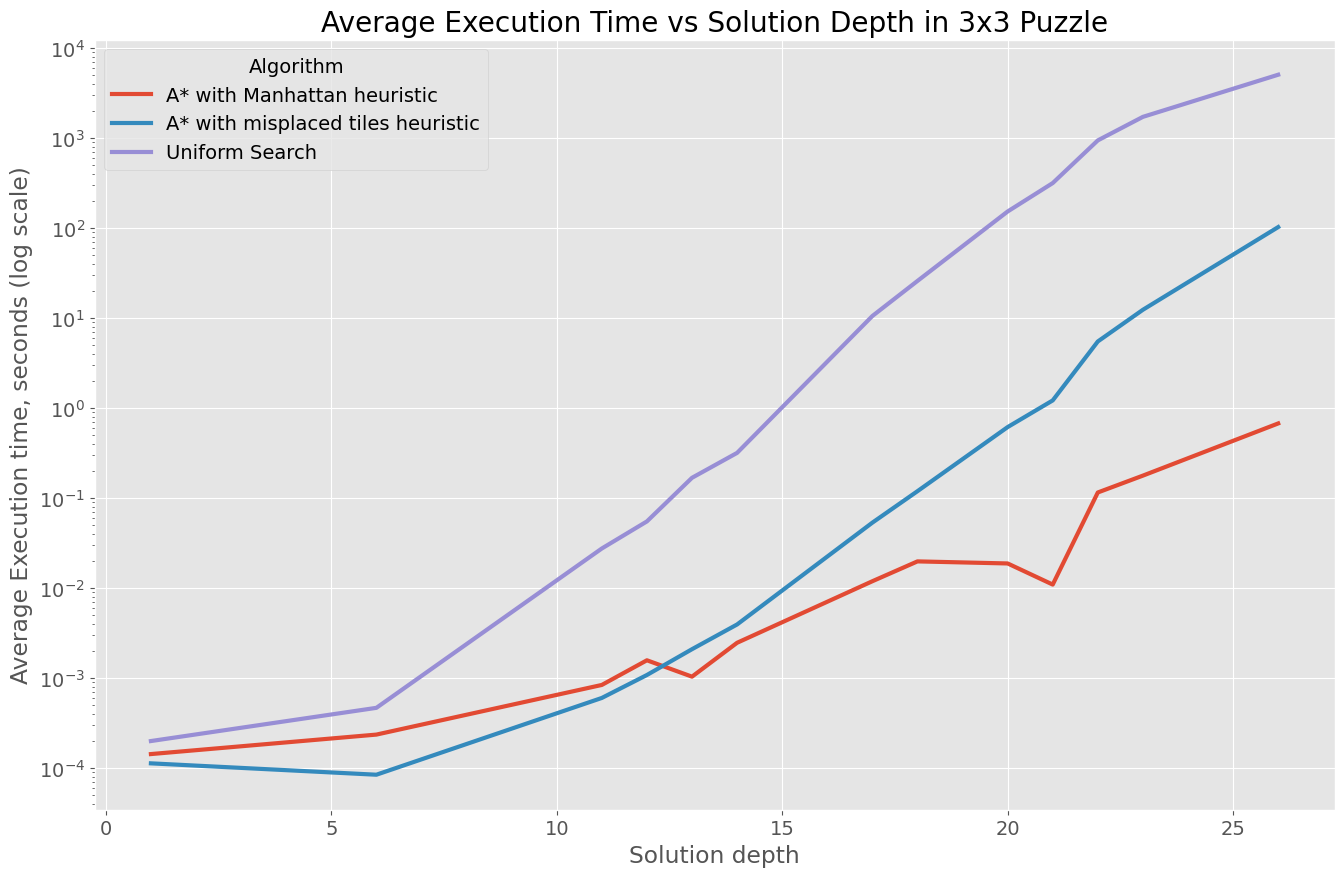

In [67]:
df.groupby(['target_level', 'algo'])['time'].mean().unstack().plot(linewidth=3)

plt.title('Average Execution Time vs Solution Depth in 3x3 Puzzle')
plt.xlabel('Solution depth')
plt.ylabel('Average Execution time, seconds (log scale)')
plt.yscale('log')
plt.legend(title='Algorithm');

plt.savefig('nodes_time_3x3.png', dpi=400, bbox_inches='tight')

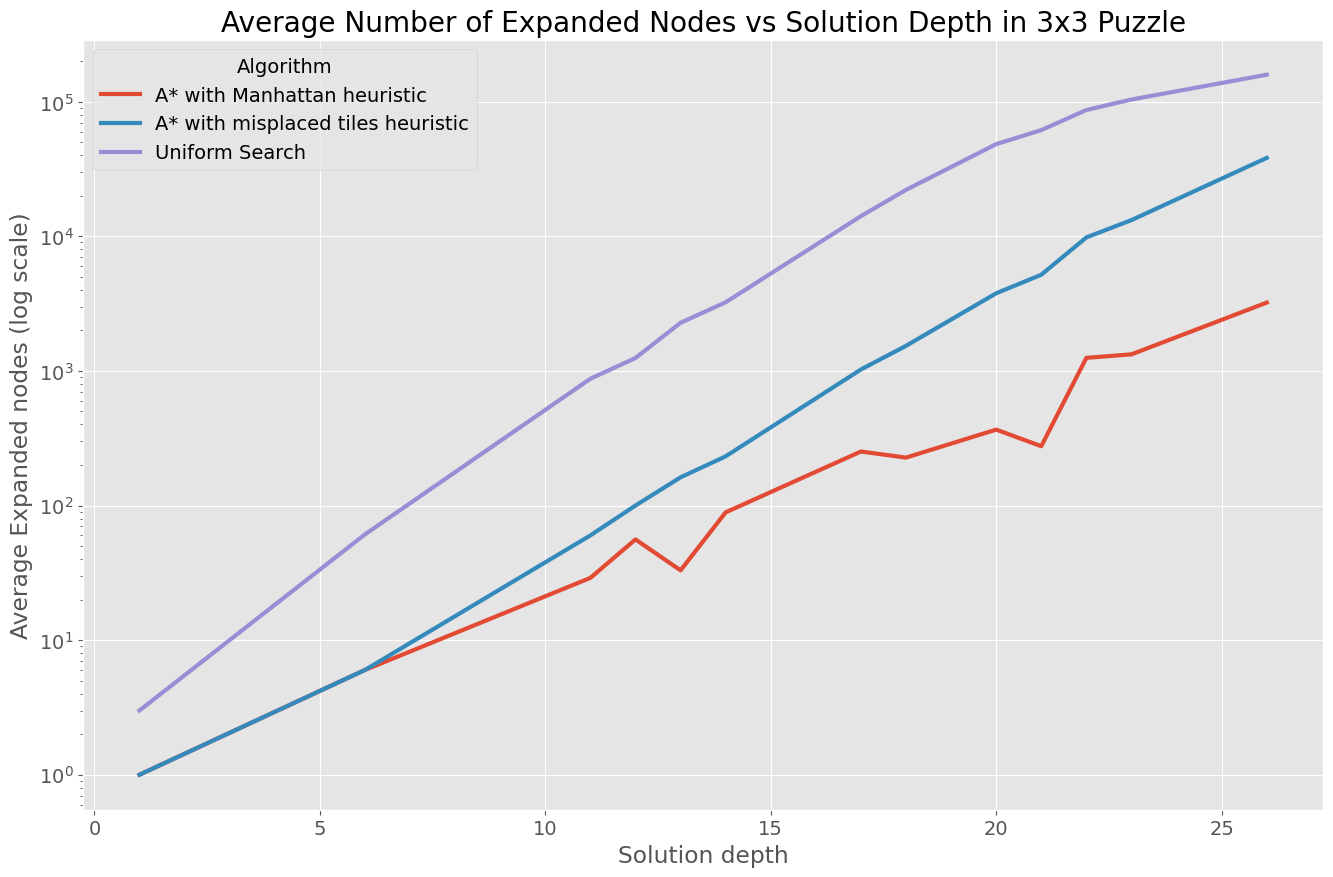

In [70]:
df.groupby(['target_level', 'algo'])['exposed_nodes'].mean().unstack().plot(linewidth=3)

plt.title('Average Number of Expanded Nodes vs Solution Depth in 3x3 Puzzle')
plt.xlabel('Solution depth')
plt.ylabel('Average Expanded nodes (log scale)')
plt.legend(title='Algorithm');
plt.yscale('log')
plt.savefig('nodes_depth_3x3.png', dpi=400, bbox_inches='tight')

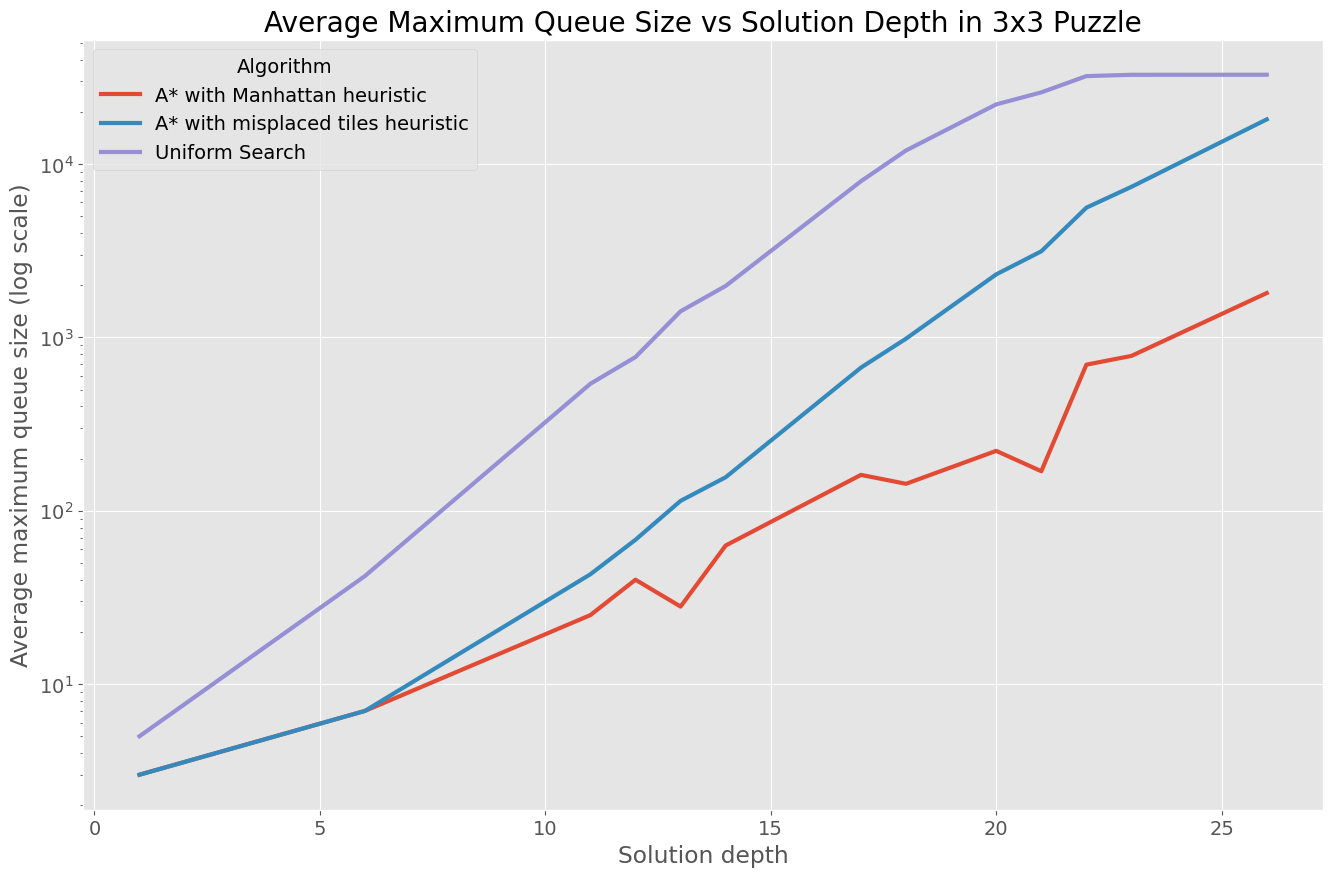

In [72]:

df.groupby(['target_level', 'algo'])['memory_usage'].mean().unstack().plot(linewidth=3)

plt.title('Average Maximum Queue Size vs Solution Depth in 3x3 Puzzle')
plt.xlabel('Solution depth')
plt.ylabel('Average maximum queue size (log scale)')
plt.legend(title='Algorithm');
plt.yscale('log')
plt.savefig('queue_depth_3x3.png', dpi=400, bbox_inches='tight')

### 4x4

In [80]:
import glob

files = glob.glob(r"C:\Users\Msi\Documents\PyCharmProjects\puzzle\results*.csv")

dfs = []
for f in files:
    df = pd.read_csv(f)
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
df = df.drop(columns=['Unnamed: 0'])
df.sort_values(by='target_level')
df.groupby(['target_level', 'algo'])[['exposed_nodes', 'memory_usage', 'time']].mean()

exposed_nodes  memory_usage  \
target_level algo                                                             
1            A* with Manhattan heuristic                  1.0           3.0   
             A* with misplaced tiles heuristic            1.0           3.0   
3            A* with Manhattan heuristic                  3.0           6.0   
             A* with misplaced tiles heuristic            3.0           6.0   
4            A* with Manhattan heuristic                  4.0           7.0   
             A* with misplaced tiles heuristic            4.0           7.0   
5            A* with Manhattan heuristic                  5.0           6.0   
             A* with misplaced tiles heuristic            5.0           6.0   
             Uniform Search                              71.0          79.0   
6            A* with Manhattan heuristic                  6.0           9.0   
             A* with misplaced tiles heuristic            6.0           9.0   
7            A* with Manhattan heuristic                  8.0          10.5   
             A* with misplaced tiles heuristic            9.0          12.0   
10           A* with Manhattan heuristic                 13.0          16.5   
             A* with misplaced tiles heuristic           14.5          18.5   
             Uniform Search                            3305.0        3233.0   
12           A* with Manhattan heuristic                 27.0          29.0   
             A* with misplaced tiles heuristic           69.0          77.0   
14           A* with Manhattan heuristic                 29.0          33.0   
             A* with misplaced tiles heuristic           72.0          75.0   
15           A* with Manhattan heuristic                159.0         164.0   
             A* with misplaced tiles heuristic          470.0         512.0   
             Uniform Search                          110621.0      102531.0   
16           A* with Manhattan heuristic                 17.0          17.0   
             A* with misplaced tiles heuristic          129.0         135.0   
18           A* with Manhattan heuristic                 48.0          59.0   
             A* with misplaced tiles heuristic          906.0         989.0   
21           A* with Manhattan heuristic                206.0         211.0   
             A* with misplaced tiles heuristic         5314.0        5510.0   
22           A* with Manhattan heuristic                280.0         322.0   
             A* with misplaced tiles heuristic         8769.0        9254.0   

                                                       time  
target_level algo                                            
1            A* with Manhattan heuristic           0.000205  
             A* with misplaced tiles heuristic     0.000055  
3            A* with Manhattan heuristic           0.000731  
             A* with misplaced tiles heuristic     0.000134  
4            A* with Manhattan heuristic           0.000422  
             A* with misplaced tiles heuristic     0.000087  
5            A* with Manhattan heuristic           0.000378  
             A* with misplaced tiles heuristic     0.000079  
             Uniform Search                        0.000771  
6            A* with Manhattan heuristic           0.000852  
             A* with misplaced tiles heuristic     0.000074  
7            A* with Manhattan heuristic           0.000537  
             A* with misplaced tiles heuristic     0.000117  
10           A* with Manhattan heuristic           0.000938  
             A* with misplaced tiles heuristic     0.000247  
             Uniform Search                        0.386834  
12           A* with Manhattan heuristic           0.001576  
             A* with misplaced tiles heuristic     0.001000  
14           A* with Manhattan heuristic           0.001652  
             A* with misplaced tiles heuristic     0.001018  
15           A* with Manhattan heuristic           0.012141  
             A

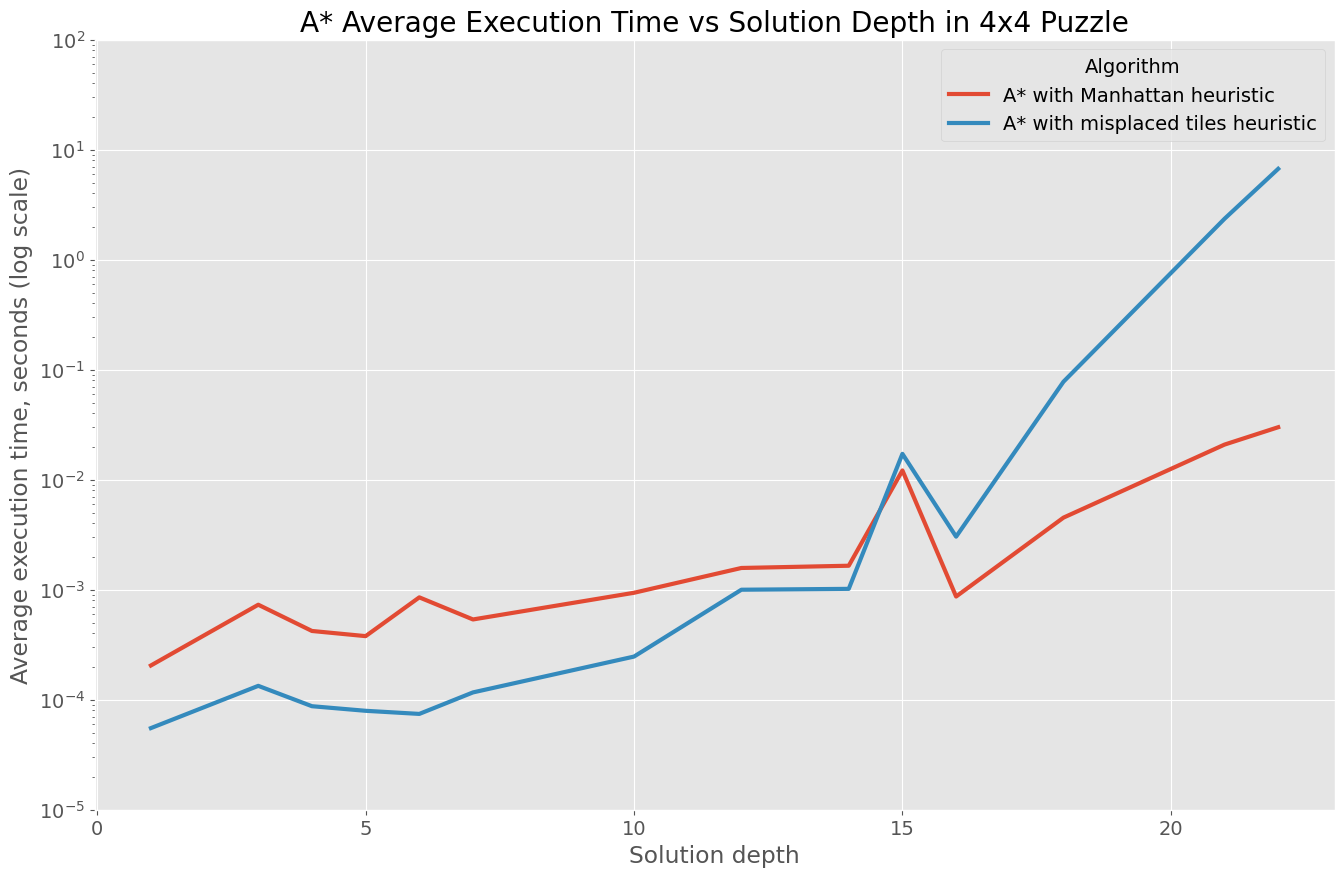

In [94]:
df1 = df[df["algo"] != "Uniform Search"]

df1.groupby(['target_level', 'algo'])['time'].mean().unstack().plot(linewidth=3)

plt.title('A* Average Execution Time vs Solution Depth in 4x4 Puzzle')
plt.xlabel('Solution depth')
plt.ylabel('Average execution time, seconds (log scale)')
plt.yscale('log')
plt.legend(title='Algorithm')
plt.ylim(1e-5, 1e2)


plt.savefig('A_star_depth_time_4x4.png', dpi=400, bbox_inches='tight')

plt.show()

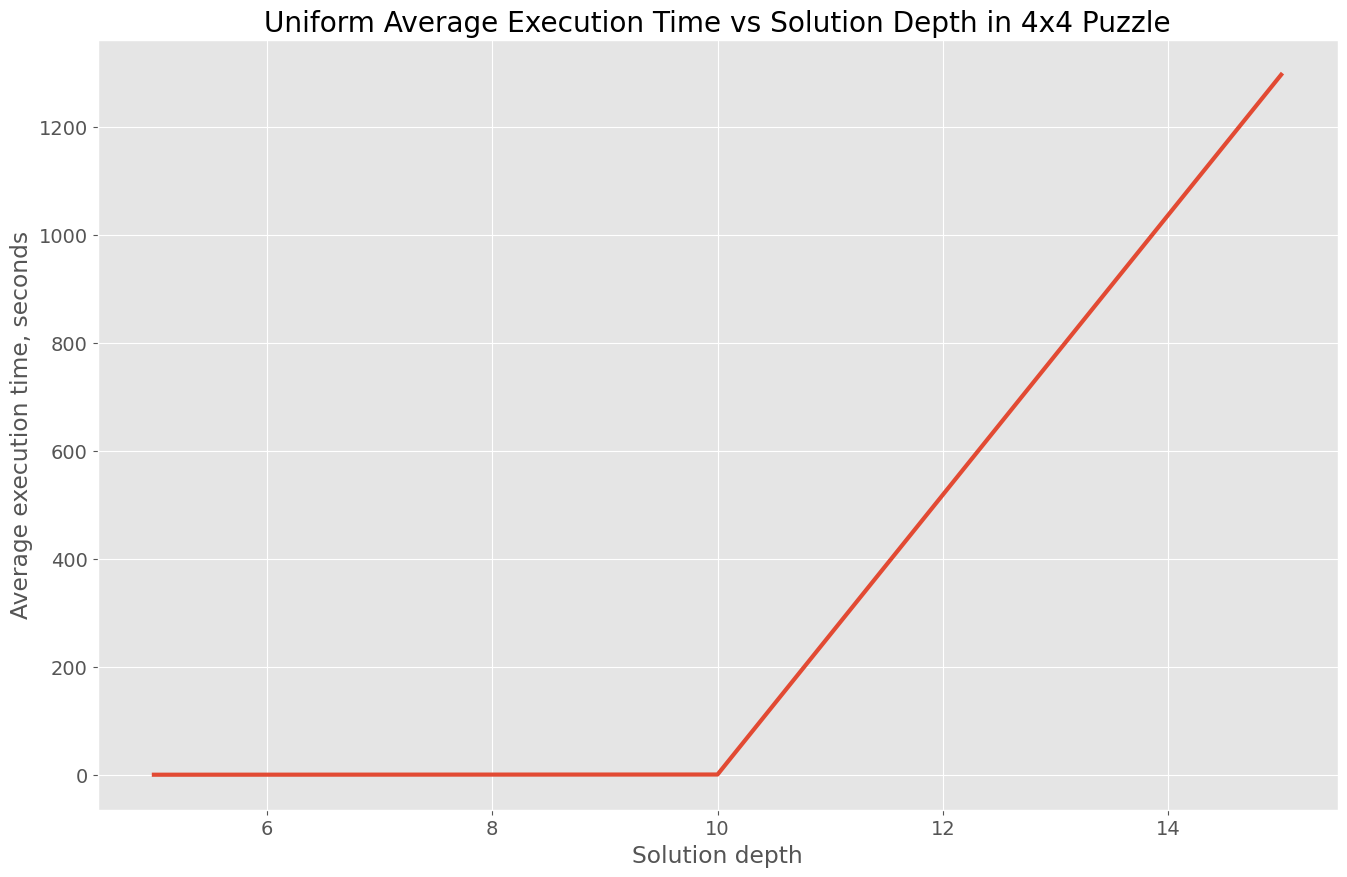

In [95]:
df2 = df[df["algo"] == "Uniform Search"]

df2.groupby(['target_level', 'algo'])['time'].mean().unstack().plot(linewidth=3)

plt.title('Uniform Average Execution Time vs Solution Depth in 4x4 Puzzle')
plt.xlabel('Solution depth')
plt.ylabel('Average execution time, seconds')
# plt.yscale('log')
# plt.legend(title='Algorithm')
# plt.ylim(1e-5, 1e2)

plt.legend().set_visible(False) 
plt.savefig('Uni_depth_time_4x4.png', dpi=400, bbox_inches='tight')
plt.show()

In [104]:
df2.groupby(['target_level', 'algo'])[['exposed_nodes', 'memory_usage', 'time']].mean().unstack()

,exposed_nodes,memory_usage,time
algo,Uniform Search,Uniform Search,Uniform Search
target_level,,,
5,71.0,79.0,0.000771
10,3305.0,3233.0,0.386834
15,110621.0,102531.0,1297.388588


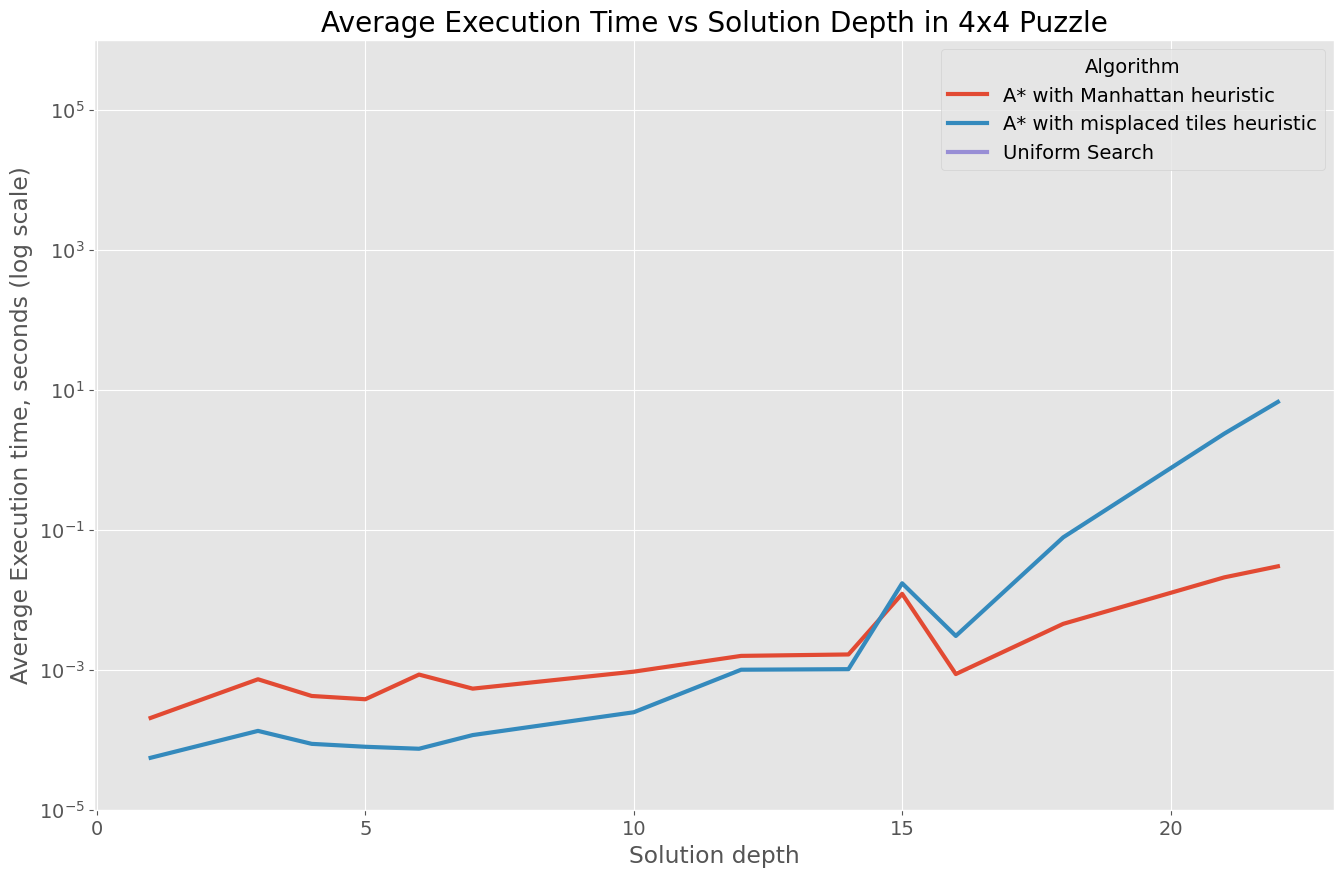

In [87]:
df.groupby(['target_level', 'algo'])['time'].mean().unstack().plot(linewidth=3)

plt.title('Average Execution Time vs Solution Depth in 4x4 Puzzle')
plt.xlabel('Solution depth')
plt.ylabel('Average Execution time, seconds (log scale)')
plt.yscale('log')
plt.legend(title='Algorithm')
plt.ylim(1e-5, 1e6);

# plt.savefig('depth_time_4x4.png', dpi=400, bbox_inches='tight')

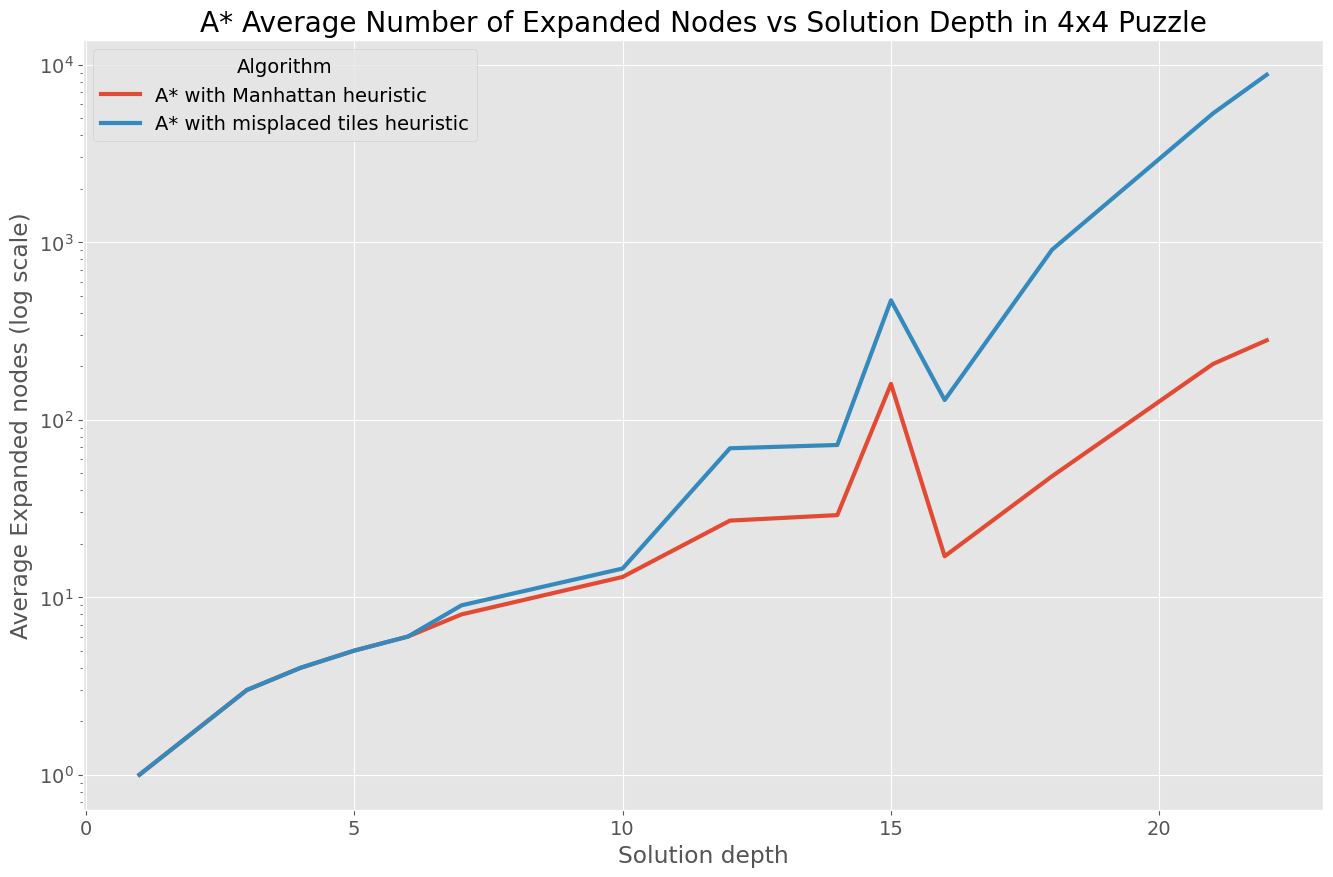

In [105]:
df1.groupby(['target_level', 'algo'])['exposed_nodes'].mean().unstack().plot(linewidth=3)

plt.title('A* Average Number of Expanded Nodes vs Solution Depth in 4x4 Puzzle')
plt.xlabel('Solution depth')
plt.ylabel('Average Expanded nodes (log scale)')
plt.legend(title='Algorithm');
plt.yscale('log')
plt.savefig('A_star_nodes_depth_4x4.png', dpi=400, bbox_inches='tight')




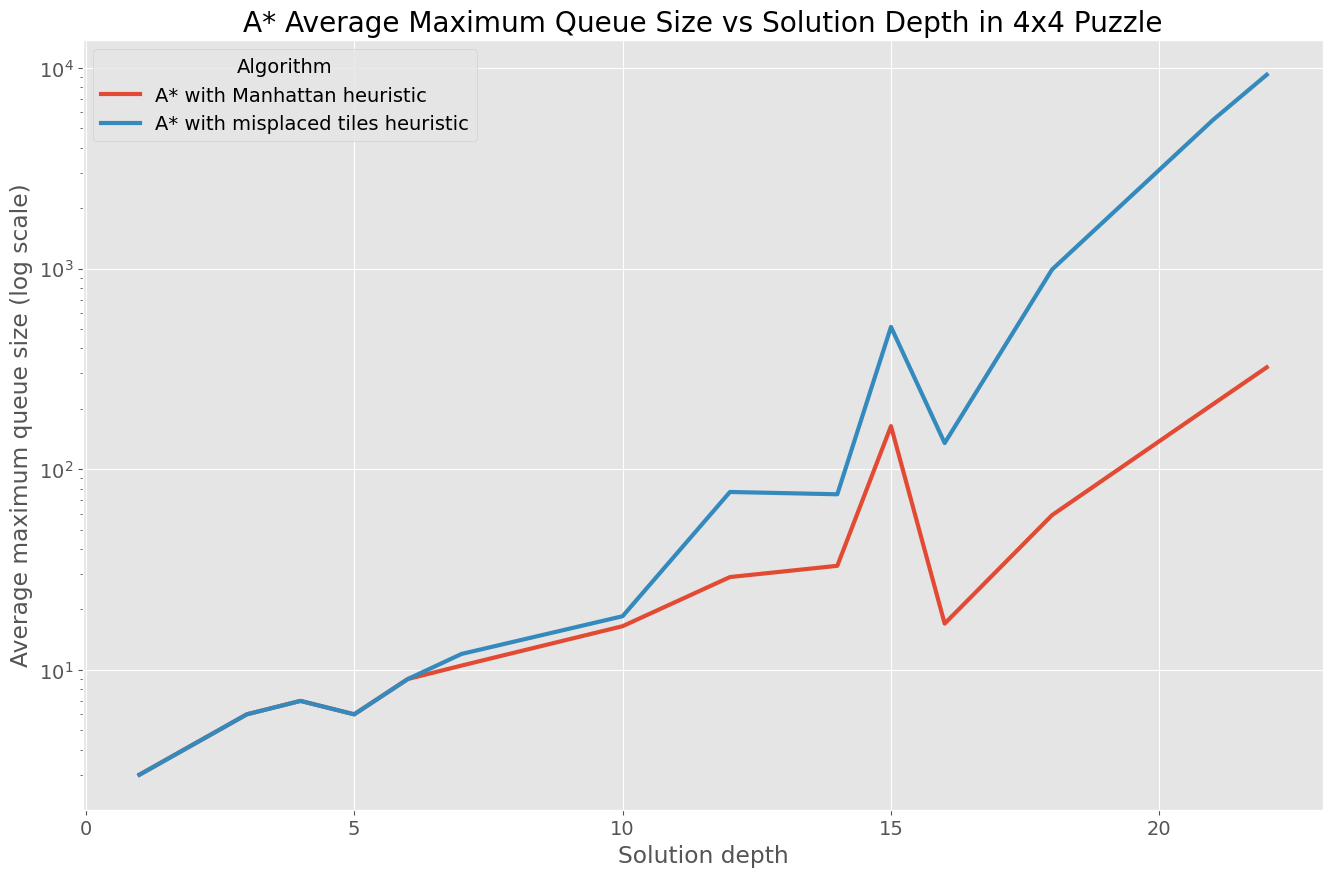

In [106]:
df1.groupby(['target_level', 'algo'])['memory_usage'].mean().unstack().plot(linewidth=3)

plt.title('A* Average Maximum Queue Size vs Solution Depth in 4x4 Puzzle')
plt.xlabel('Solution depth')
plt.ylabel('Average maximum queue size (log scale)')
plt.legend(title='Algorithm');
plt.yscale('log')
plt.savefig('A_star_queue_depth_4x4.png', dpi=400, bbox_inches='tight')